Objective is to _"write some code simulating a poisson process"_

Starting here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

A Poisson process models random events occurring in time (or space) where:
- Events occur independently
- The average rate of events is constant: 𝜆
- Number of events through time N(t)

Note that there is a difference between a Poisson process and a compound Poisson process

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fractions
import scipy
from matplotlib.collections import LineCollection
import jump_process # dans .py 
from scipy.stats import poisson

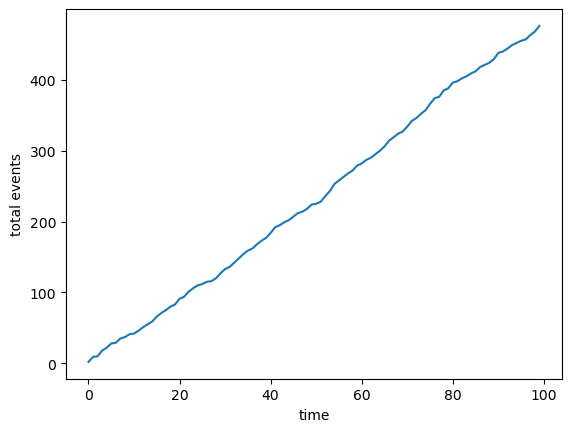

In [2]:
# rate 
lam = 5

# number of time intervals
T = 100

# simulate counts per interval
    #rvs(mu, loc=0, size=1, random_state=None)
events = poisson.rvs(mu=lam, size=T) # random variates 

# cumulative number of events
cumulative_events = np.cumsum(events)

plt.plot(cumulative_events)
plt.xlabel("time")
plt.ylabel("total events")
plt.show()

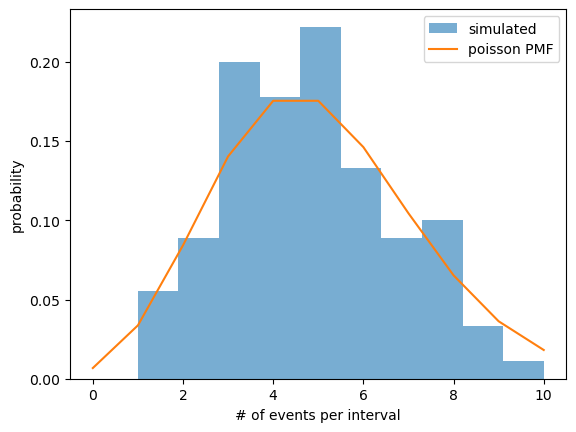

theoretical mean: 5.0
theoretical variance: 5.0
theoretical std: 2.23606797749979
theoretical median: 5.0


In [3]:
#looking at a probability mass function 
# possible event counts
k = np.arange(0, max(events)+1)

# theoretical PMF
pmf = poisson.pmf(k, mu=lam)

# histogram of simulated data
plt.hist(events, bins= 10, density=True, alpha=0.6, label="simulated")

# theoretical PMF
plt.plot(k, pmf, '-', label="poisson PMF")
plt.xlabel("# of events per interval")
plt.ylabel("probability")
plt.legend()
plt.show()

print("theoretical mean:", poisson.mean(mu=lam))
print("theoretical variance:", poisson.var(mu=lam))
print("theoretical std:", poisson.std(mu=lam))
print("theoretical median:", poisson.median(mu=lam))

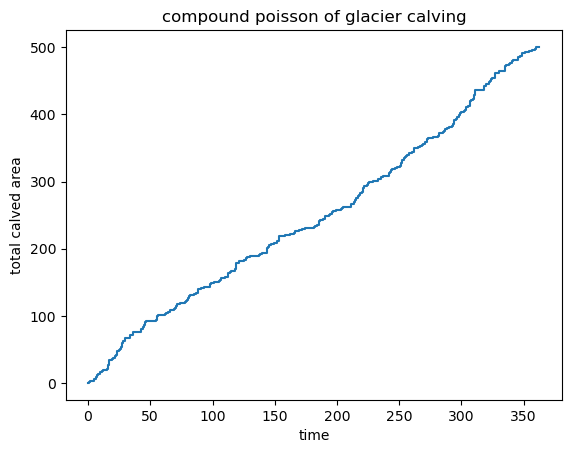

In [4]:
# so for glacial calving
#  if there is 1 event per day and we look at 365 days

L = 1 # event per day
T = 365 # days

# number of events 
N = np.random.poisson(L * T) #total number of calving events in a year

# event times - randomly distributed in the year
event_times = np.sort(np.random.uniform(0, T, N))

# glacier size
sizes = np.random.lognormal(mean=0, sigma=0.8, size = N)

# cumulative calved area
calved_area = np.cumsum(sizes)

plt.step(event_times, calved_area)
plt.xlabel("time")
plt.ylabel("total calved area")
plt.title("compound poisson of glacier calving")
plt.show()

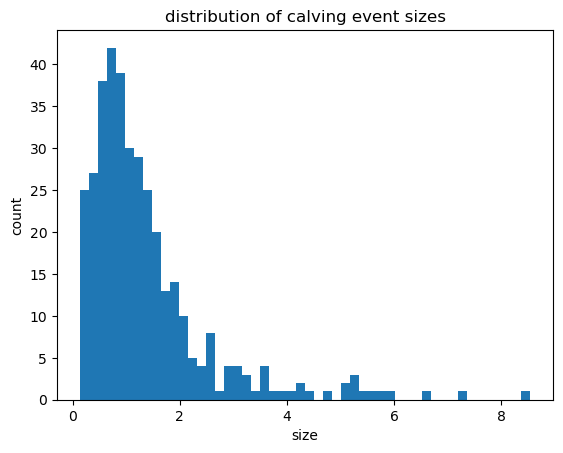

In [5]:
plt.hist(sizes, bins=50)
plt.xlabel("size")
plt.ylabel("count")
plt.title("distribution of calving event sizes")
plt.show()

In [17]:
calving_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/Jakobshavn-Isbrae-CalvingStatistics/jakobshavn_calving_length_ts.csv"
df = pd.read_csv(calving_path, parse_dates=["Date"])

df = df.sort_values("Date").reset_index(drop=True)
df = df.dropna(subset=["calving_magnitude"]).reset_index(drop=True)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sofiasuhinin/Desktop/GrIS_Calving/Jakobshavn-Isbrae-CalvingStatistics/jakobshavn_calving_length_ts.csv'

In [7]:
# colors
dark_blue = "#1f3a5f"
light_blue = "#9ecae1"
middle_blue = "#6baed6"
teal = "#2a9d8f"

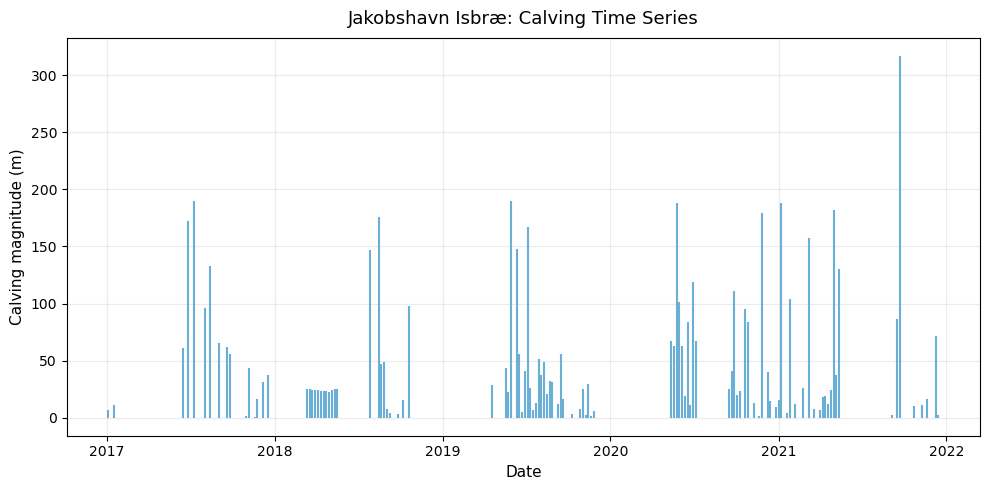

In [16]:
# cut to 2017
# cut to 2017
terminus_plot = df[df["Date"] >= "2017"].copy()

# mask negative values
terminus_plot["calving_positive"] = terminus_plot["calving_magnitude"].where(terminus_plot["calving_magnitude"] > 0)


plt.figure(figsize=(10, 5))

plt.vlines(terminus_plot["Date"], ymin = 0, ymax = terminus_plot["calving_positive"], color=middle_blue)
plt.xlabel("Date", fontsize = 11)
plt.ylabel("Calving magnitude (m)", fontsize = 11)
plt.title("Jakobshavn Isbræ: Calving Time Series", fontsize = 13, pad = 10)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [9]:
# attempt w/o glacier velocity stuff first
    # aim is to change event size and time in between events to create a synthetic data set that looks like mine

# generate rndm event times
    #time_scale is what i can change

def event_times(start_date, end_date, time_scale, seed=None):
    rng = np.random.default_rng(seed)

    current_time = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)
    event_times = []

    while current_time < end_date:
        wait_days = rng.exponential(scale=time_scale)
        current_time += pd.Timedelta(days=wait_days)

        if current_time < end_date:
            event_times.append(current_time)

    return pd.to_datetime(event_times)

# event_size generation 

def event_sizes(event_times, size_scale, seed=None):
    rng = np.random.default_rng(seed)

    sizes = rng.exponential(scale=size_scale, size=len(event_times))

    return pd.DataFrame({"Date": event_times, "synthetic_calving": sizes})


def event_sizes_gamma(event_times, shape, scale, seed=None):
    rng = np.random.default_rng(seed)
    sizes = rng.gamma(shape=shape, scale=scale, size=len(event_times))
    return pd.DataFrame({"Date": event_times, "synthetic_calving": sizes})

In [10]:
observed = terminus_plot[["Date", "calving_positive"]].copy()
observed = observed.dropna()
observed = observed[observed["calving_positive"] > 0]

In [11]:
# exponential synthetic data

good_times = event_times(
    start_date="2017-01-01",
    end_date="2021-12-31",
    time_scale=20,
    seed=42
)

good_syn = event_sizes(
    good_times,
    size_scale=70,
    seed=42
)

bad_times = event_times(
    start_date="2017-01-01",
    end_date="2021-12-31",
    time_scale=40,
    seed=24
)

bad_syn = event_sizes(
   bad_times,
   size_scale=20,
   seed=24
)


In [12]:
# gamma synthetic data
good_times = event_times(
    start_date="2017-01-01",
    end_date="2021-12-31",
    time_scale=12,  
    seed=42
)

good_syn = event_sizes_gamma(
    good_times,
    shape=6,         # controls spread / peak
    scale=10,        # mean ≈ shape * scale = 60
    seed=42
)


bad_times = event_times(
    start_date="2017-01-01",
    end_date="2021-12-31",
    time_scale=40,   # too sparse
    seed=24
)

bad_syn = event_sizes_gamma(
    bad_times,
    shape=1.5,         # more skewed (worse fit)
    scale=8,        # mean ≈ 20 (too small)
    seed=24
)

In [13]:
# compute interarrival times
observed["dt_days"] = observed["Date"].diff().dt.days
good_syn["dt_days"] = good_syn["Date"].diff().dt.days
bad_syn["dt_days"] = bad_syn["Date"].diff().dt.days

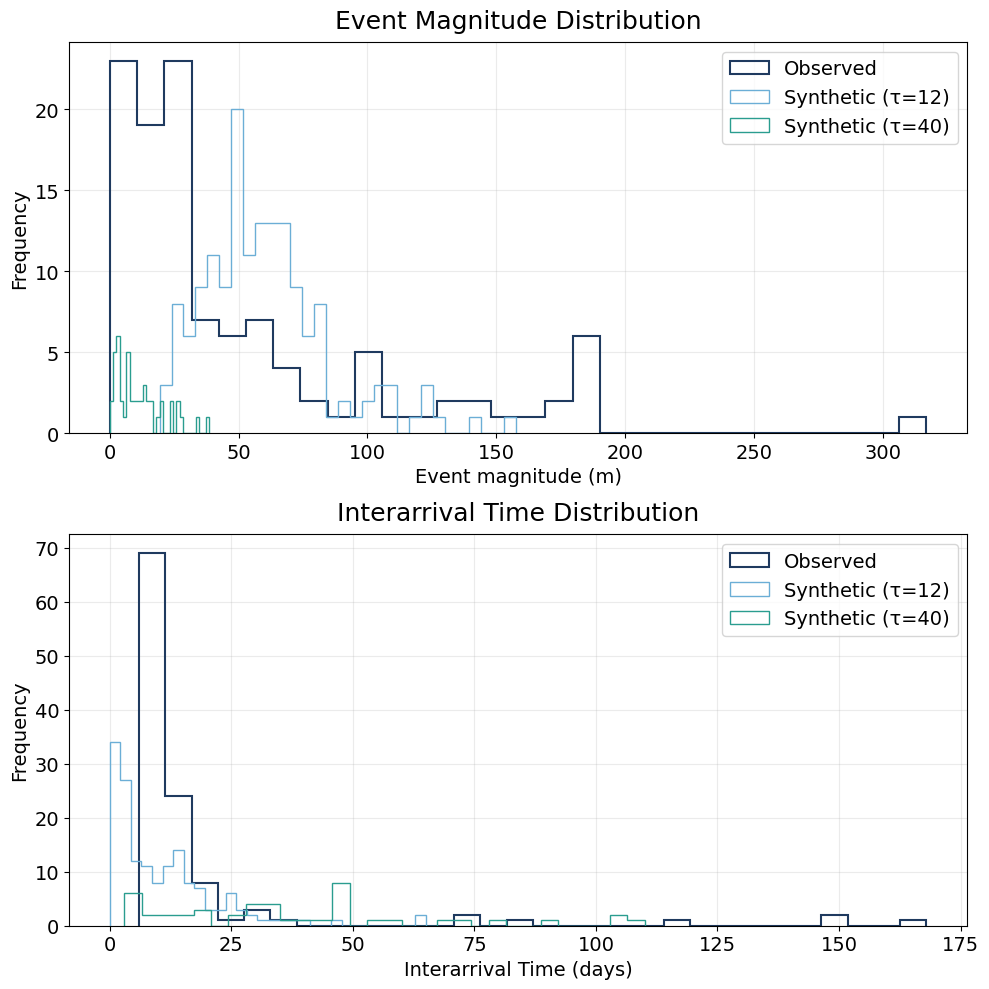

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

ax[0].hist(
    observed["calving_positive"],
    bins=30,
    histtype="step",
    linewidth=1.5,
    color = dark_blue,
    label="Observed"
)

ax[0].hist(
    good_syn["synthetic_calving"],
    bins=30,
    histtype="step",
    linewidth=1,
    color = middle_blue,
    label="Synthetic (τ=12)"
)

ax[0].hist(
    bad_syn["synthetic_calving"],
    bins=30,
    histtype="step",
    linewidth=1,
    color = teal,
    label="Synthetic (τ=40)"
)

ax[0].set_xlabel("Event magnitude (m)", fontsize=14)
ax[0].set_ylabel("Frequency", fontsize=14)
ax[0].set_title("Event Magnitude Distribution", fontsize=18, pad = 10)
ax[0].grid(True, alpha=0.25)   
ax[0].tick_params(labelsize=14) 
ax[0].legend(fontsize=14)


ax[1].hist(
    observed["dt_days"].dropna(),
    bins=30,
    histtype="step",
    linewidth=1.5,
    color = dark_blue,
    label="Observed"
)

ax[1].hist(
    good_syn["dt_days"].dropna(),
    bins=30,
    histtype="step",
    linewidth=1,
    color = middle_blue,
    label="Synthetic (τ=12)"
)

ax[1].hist(
    bad_syn["dt_days"].dropna(),
    bins=30,
    histtype="step",
    linewidth=1,
    color = teal,
    label="Synthetic (τ=40)"
)

ax[1].set_xlabel("Interarrival Time (days)", fontsize=14)
ax[1].set_ylabel("Frequency", fontsize=14)
ax[1].set_title("Interarrival Time Distribution", fontsize=18, pad=10)
ax[1].grid(True, alpha=0.25)
ax[1].tick_params(labelsize=14) 
ax[1].legend(fontsize=14)

plt.tight_layout()
plt.show()

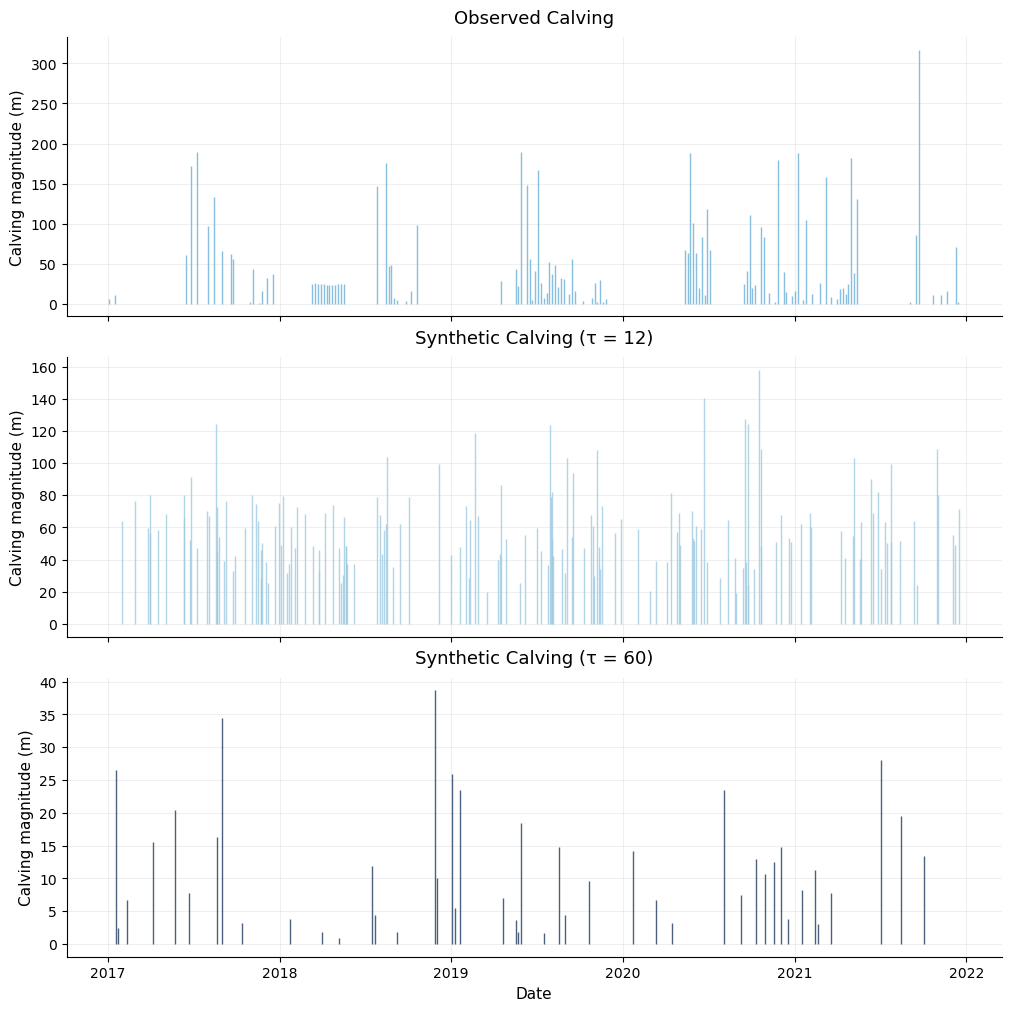

In [15]:


fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, constrained_layout=True)

# observed
axes[0].vlines(
    observed["Date"],
    ymin=0,
    ymax=observed["calving_positive"],
    color=middle_blue,
    linewidth=1,
    alpha=0.8
)
axes[0].set_title("Observed Calving", fontsize = 13, pad = 10)
axes[0].set_ylabel("Calving magnitude (m)", fontsize = 11)

# good synthetic
axes[1].vlines(
    good_syn["Date"],
    ymin=0,
    ymax=good_syn["synthetic_calving"],
    color=light_blue,
    linewidth=1,
    alpha=0.8
)
axes[1].set_title("Synthetic Calving (τ = 12)", fontsize = 13, pad = 10)
axes[1].set_ylabel("Calving magnitude (m)", fontsize = 11)

# bad synthetic
axes[2].vlines(
    bad_syn["Date"],
    ymin=0,
    ymax=bad_syn["synthetic_calving"],
    color=dark_blue,
    linewidth=1,
    alpha=0.8
)
axes[2].set_title("Synthetic Calving (τ = 60)", fontsize = 13, pad = 10)
axes[2].set_ylabel("Calving magnitude (m)", fontsize = 11)
axes[2].set_xlabel("Date", fontsize = 11)

for ax in axes:
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()